<a href="https://colab.research.google.com/github/EmanueleDeCandia/Logistica-Vending-Machine/blob/main/Analisi_incertezza_OCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisi dell'incertezza con simulazione Monte Carlo**

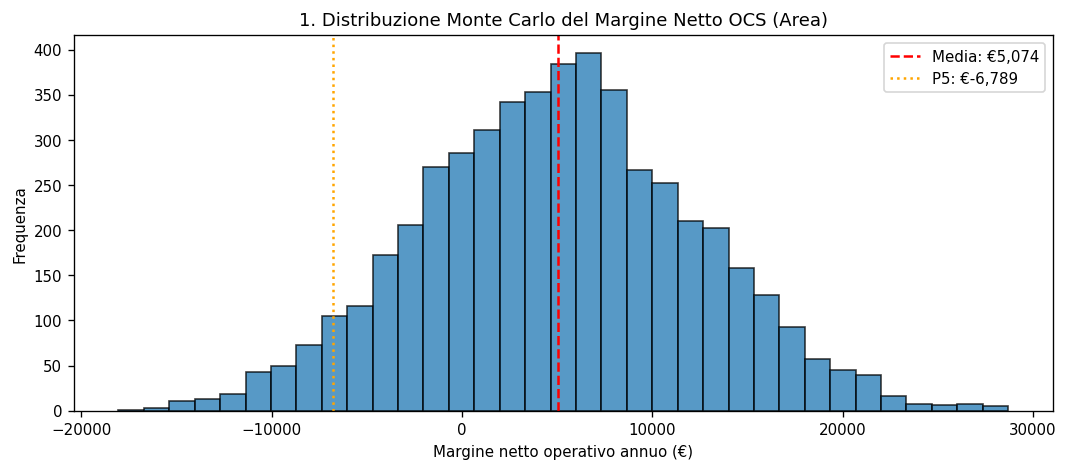

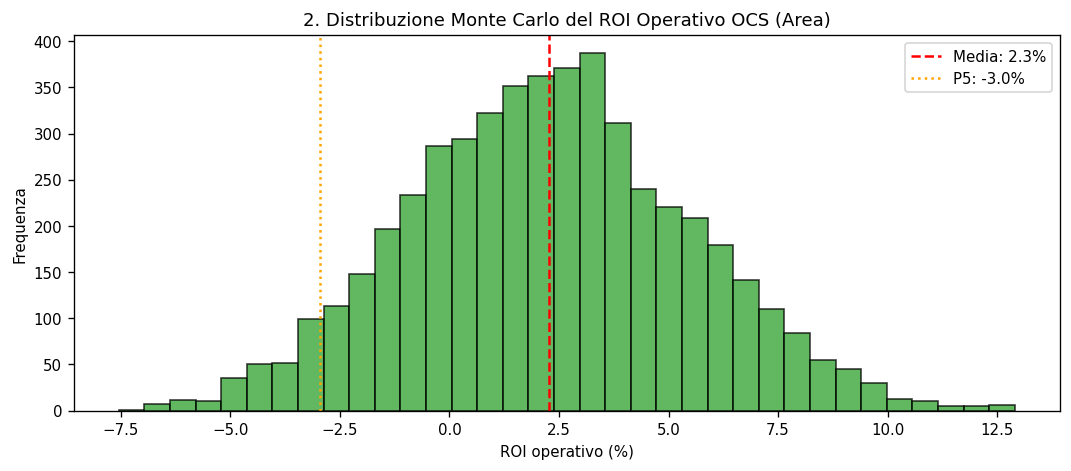

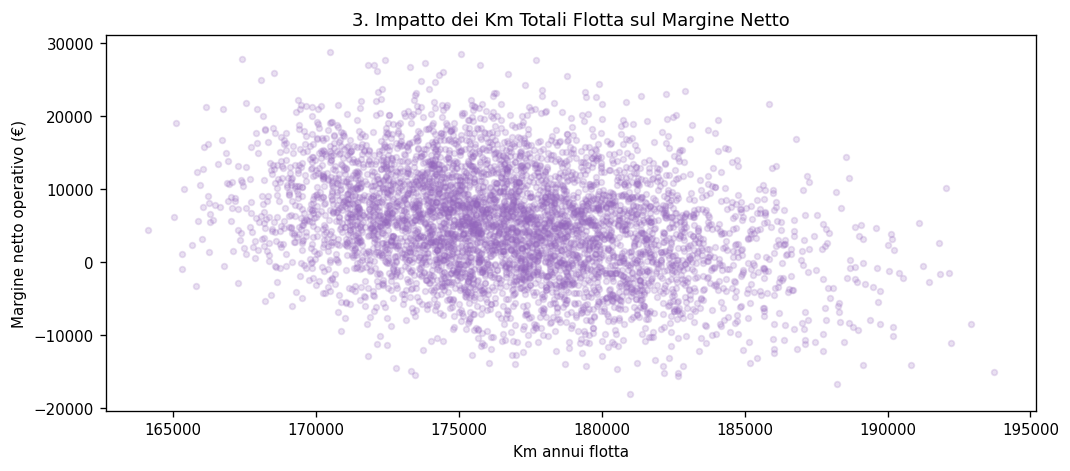

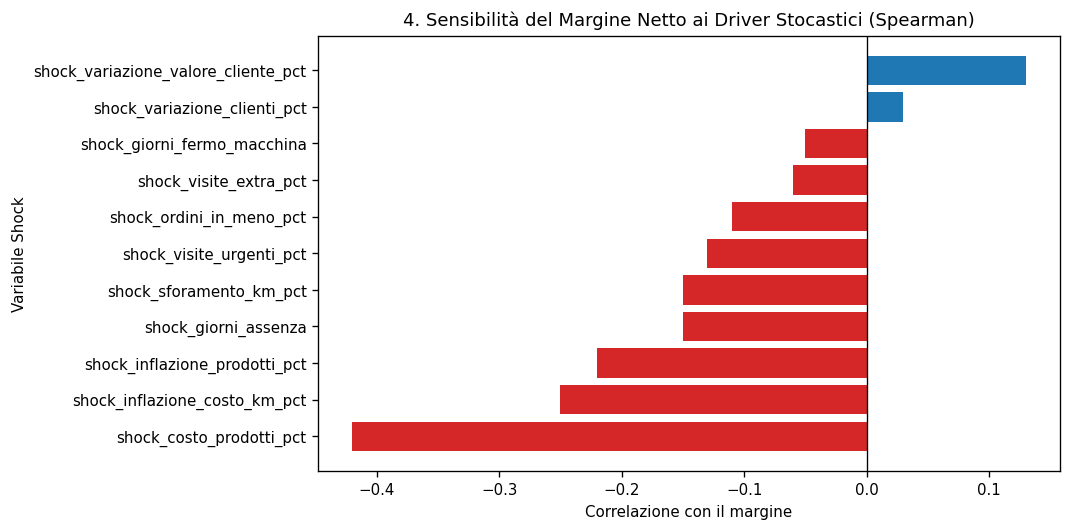

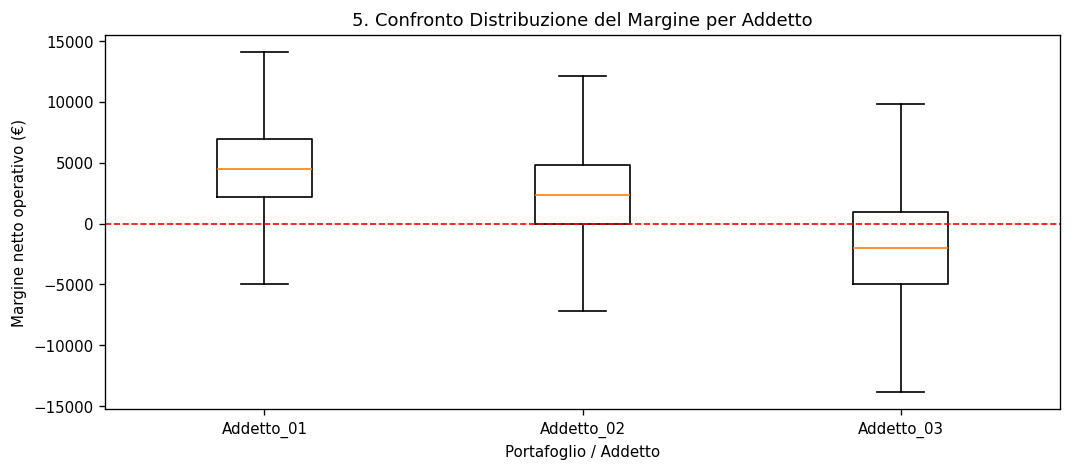

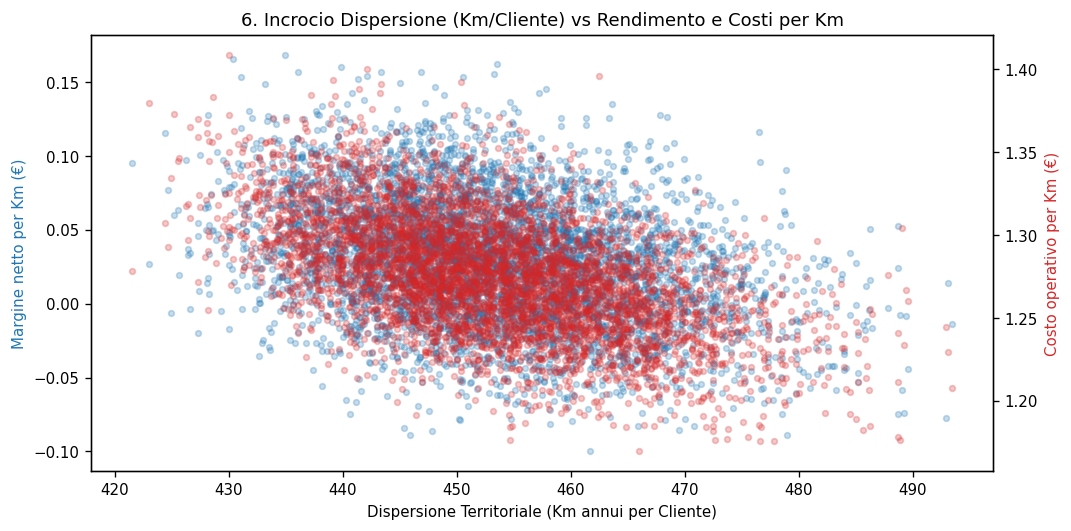

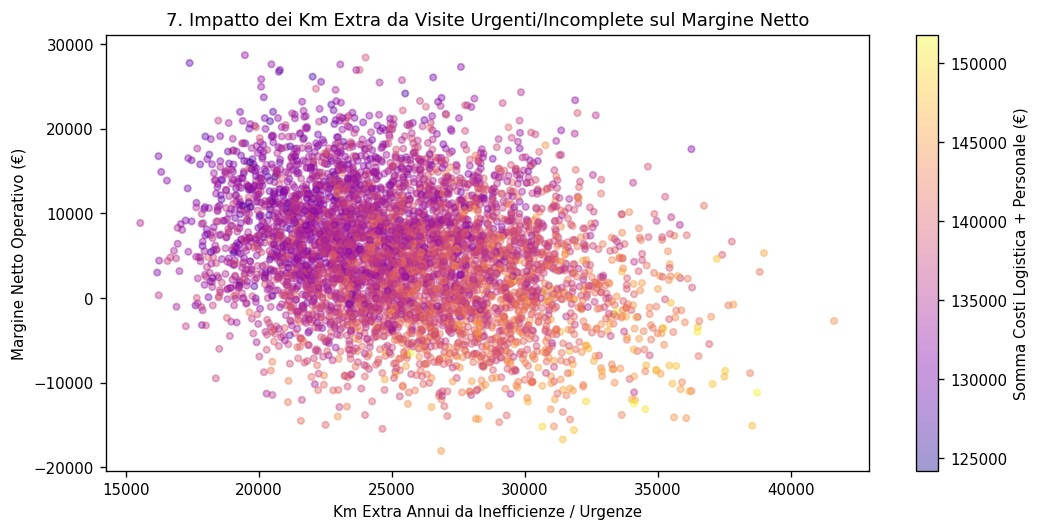

 SINTESI COMPLETA AREA REGIONALE (TUTTE LE VARIABILI CALCOLATE - INCLUSA SATURAZIONE)


,area,indicatore,P5,media,mediana_P50,P95,deviazione_standard,probabilita_negativo
0,Marche,clienti_attivi,386.00,390.05,390.00,394.00,2.25,0.00
1,Marche,macchine_attive,455.00,459.05,459.00,463.00,2.25,0.00
2,Marche,visite_programmate_anno,4632.00,4680.59,4680.00,4728.00,26.97,0.00
3,Marche,visite_extra_anno,117.30,159.62,156.90,206.47,26.87,0.00
4,Marche,visite_urgenti_anno,379.20,467.03,466.20,555.80,48.29,0.00
5,Marche,visite_totali_anno,5203.49,5307.24,5307.22,5410.85,62.87,0.00
6,Marche,km_totali,169875.53,176714.89,176491.85,184334.45,4427.20,0.00
7,Marche,km_extra,19551.98,25477.76,25224.89,32112.63,3830.10,0.00
8,Marche,ore_servizio,668.13,680.39,680.32,692.87,7.51,0.00
9,Marche,ore_guida,4853.59,5049.00,5042.62,5266.70,126.49,0.00



 SINTESI PER SINGOLO ADDETTO (TUTTE LE VARIABILI CALCOLATE)


,addetto,indicatore,P5,media,mediana_P50,P95,deviazione_standard,probabilita_negativo
0,Addetto_01,saturazione_operativa,0.75,0.80,0.80,0.87,0.04,0.00
1,Addetto_01,sovraccarico_operativo,0.00,0.00,0.00,0.00,0.00,0.00
2,Addetto_01,ore_richieste,1560.23,1667.89,1660.84,1799.49,72.29,0.00
3,Addetto_01,ore_disponibili,2032.49,2072.23,2072.26,2111.49,21.70,0.00
4,Addetto_01,ore_servizio,219.90,226.72,226.71,234.00,4.31,0.00
5,Addetto_01,ore_guida,1338.13,1441.17,1434.67,1569.08,69.75,0.00
6,Addetto_01,ore_straordinario,0.00,0.00,0.00,0.00,0.00,0.00
7,Addetto_01,clienti_attivi,128.00,129.98,130.00,132.00,1.30,0.00
8,Addetto_01,macchine_attive,151.00,152.98,153.00,155.00,1.30,0.00
9,Addetto_01,visite_programmate_anno,1536.00,1559.80,1560.00,1584.00,15.58,0.00


In [ ]:
# ==============================================================================
# Monte Carlo OCS Avanzato: Rischio Logistico, Segmentazione ABC & Densità
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configurazione display per Google Colab
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

SEED = 42
N_SIMULATIONS = 5_000
UNCERTAINTY_MULTIPLIER = 1.0

GIORNI_LAVORATIVI_MESE = 22
MESI_ANNO = 12
GIORNI_LAVORATIVI_ANNO = GIORNI_LAVORATIVI_MESE * MESI_ANNO
ORE_LAVORATIVE_GIORNO = 8.0
VELOCITA_MEDIA_KMH = 35

OUTPUT_DIR = Path("output_monte_carlo_ocs")

# ==============================================================================
# CONFIGURAZIONE PORTAFOGLI ADDETTI CON SEGMENTAZIONE ABC
# ==============================================================================
# Nota: Per escludere il 3° Addetto dal calcolo, basta commentare le righe del suo blocco con '#'
# Per riattivarlo, rimuovere il '#' iniziale.
PORTAFOGLI_ADDETTI = [
    {
        "area": "Marche",
        "addetto": "Addetto_01",
        "km_annui_base": 40_000,
        "costo_lavoro_annuo_base": 29_000,
        "costo_km_base": 0.22,
        "costo_manutenzione_macchina_base": 20,
        "frequenza_mensile_base": 1.0,
        "clusters": {
            "A_KeyAccount": {"n_clienti": 10, "valore_medio": 1300, "sd_valore": 1100, "minuti_servizio": 20, "macchine_per_cliente": 2.5},
            "B_Medium":     {"n_clienti": 20, "valore_medio": 700, "sd_valore": 300,  "minuti_servizio": 15, "macchine_per_cliente": 1.4},
            "C_Small":      {"n_clienti": 100, "valore_medio": 500,  "sd_valore": 160,  "minuti_servizio": 5, "macchine_per_cliente": 1.0},
        }
    },
    {
        "area": "Marche",
        "addetto": "Addetto_02",
        "km_annui_base": 48_000,
        "costo_lavoro_annuo_base": 29_000,
        "costo_km_base": 0.22,
        "costo_manutenzione_macchina_base": 20,
        "frequenza_mensile_base": 1.0,
        "clusters": {
            "A_KeyAccount": {"n_clienti": 10, "valore_medio": 1300, "sd_valore": 1100, "minuti_servizio": 20, "macchine_per_cliente": 2.5},
            "B_Medium":     {"n_clienti": 20, "valore_medio": 700, "sd_valore": 300,  "minuti_servizio": 15, "macchine_per_cliente": 1.4},
            "C_Small":      {"n_clienti": 100, "valore_medio": 500,  "sd_valore": 160,  "minuti_servizio": 5, "macchine_per_cliente": 1.0},
        }
    },
    # --- ADDETTO 03 (TOGGLE: Aggiungi/Rimuovi '#' per disattivare/attivare) ---
    {
        "area": "Marche",
        "addetto": "Addetto_03",
        "km_annui_base": 56_000,
        "costo_lavoro_annuo_base": 29_000,
        "costo_km_base": 0.22,
        "costo_manutenzione_macchina_base": 20,
        "frequenza_mensile_base": 1.0,
        "clusters": {
            "A_KeyAccount": {"n_clienti": 10, "valore_medio": 1300, "sd_valore": 1150, "minuti_servizio": 20, "macchine_per_cliente": 2.5},
            "B_Medium":     {"n_clienti": 20, "valore_medio": 700, "sd_valore": 300,  "minuti_servizio": 15, "macchine_per_cliente": 1.4},
            "C_Small":      {"n_clienti": 100, "valore_medio": 500,  "sd_valore": 160,  "minuti_servizio": 5, "macchine_per_cliente": 1.0},
        }
    },
]

SHOCKS = {
    # DOMANDA E CLIENTI
    "variazione_clienti_pct": dict(mean=0.00, sd=0.015, min=-0.02, max=0.02),
    "variazione_valore_cliente_pct": dict(mean=0.00, sd=0.05, min=-0.01, max=0.015),
    "ordini_in_meno_pct": dict(mean=0.000, sd=0.010, min=-0.10, max=0.10),
    "rettifiche_ricavi_pct": dict(mean=0.000, sd=0.010, min=-0.05, max=0.05),

    # VISITE E PERCORSI
    "visite_extra_ordini_incompleti_pct": dict(mean=0.030, sd=0.020, min=0.025, max=0.05),
    "visite_urgenti_pct": dict(mean=0.10, sd=0.05, min=0.08, max=0.12),
    "sforamento_km_percorso_pct": dict(mean=0.05, sd=0.025, min=0.01, max=0.10),
    "km_extra_per_visita": dict(mean=40.0, sd=10.0, min=30.0, max=60.0),

    # PERSONALE
    "giorni_assenza_addetto": dict(mean=5.0, sd=3.0, min=0.0, max=10.0),
    "costo_sostituzione_giorno": dict(mean=185.0, sd=30.0, min=100.0, max=300.0),
    "costo_straordinario_ora": dict(mean=28.0, sd=4.0, min=18.0, max=45.0),

    # MACCHINE OCS
    "giorni_fermo_macchina_per_cliente": dict(mean=2.0, sd=1.2, min=0.0, max=8.0),
    "quota_ricavo_persa_durante_fermo": dict(mean=0.65, sd=0.12, min=0.20, max=1.00),
    "guasti_straordinari_per_100_macchine": dict(mean=5.0, sd=3.0, min=1.0, max=15.0),
    "costo_medio_intervento_guasto": dict(mean=145.0, sd=40.0, min=50.0, max=350.0),

    # PRODOTTI E LOGISTICA
    "costo_prodotti_pct_ricavi": dict(mean=0.30, sd=0.045, min=0.28, max=0.33),
    "inflazione_prodotti_pct": dict(mean=0.085, sd=0.025, min=0.03, max=0.15),
    "inflazione_costo_km_pct": dict(mean=0.155, sd=0.050, min=-0.09, max=0.28),
    "variazione_manutenzione_pct": dict(mean=0.00, sd=0.12, min=-0.10, max=0.20),
}


def gauss(rng, cfg, n):
    values = rng.normal(cfg["mean"], cfg["sd"] * UNCERTAINTY_MULTIPLIER, n)
    return np.clip(values, cfg["min"], cfg["max"])


def draw_all(rng, n):
    return {name: gauss(rng, cfg, n) for name, cfg in SHOCKS.items()}


def div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.divide(a, b, out=np.zeros_like(a), where=b != 0)


def simula_addetto(cfg, macro, rng, n):
    s = draw_all(rng, n)
    s["inflazione_prodotti_pct"] = macro["inflazione_prodotti_pct"]
    s["inflazione_costo_km_pct"] = macro["inflazione_costo_km_pct"]

    # --- SIMULAZIONE LOG-NORMALE ABC DEI CLIENTI ---
    tot_clienti_base = sum(c["n_clienti"] for c in cfg["clusters"].values())
    clienti_factor = 1 + s["variazione_clienti_pct"]

    ricavi_lordi_clusters = np.zeros(n)
    macchine_totali = np.zeros(n)
    minuti_servizio_totali = np.zeros(n)
    tot_clienti_effettivi = np.zeros(n)

    for c_name, c_info in cfg["clusters"].items():
        n_c_effettivi = np.maximum(np.rint(c_info["n_clienti"] * clienti_factor).astype(int), 1)
        tot_clienti_effettivi += n_c_effettivi

        # Parametri per distribuzione Log-Normale del valore cliente
        m = c_info["valore_medio"]
        v = c_info["sd_valore"] ** 2
        sigma_log = np.sqrt(np.log(1 + v / (m ** 2)))
        mu_log = np.log(m) - 0.5 * (sigma_log ** 2)

        # Campionamento stocastico vettorializzato per ogni simulazione
        max_n_c = int(np.max(n_c_effettivi))
        raw_lognormal_draws = rng.lognormal(mu_log, sigma_log, size=(n, max_n_c))

        # Somma del fatturato del cluster per ciascuna simulazione
        cluster_revenues = np.array([
            raw_lognormal_draws[i, :n_c_effettivi[i]].sum() for i in range(n)
        ])
        ricavi_lordi_clusters += cluster_revenues
        macchine_totali += n_c_effettivi * c_info["macchine_per_cliente"]
        minuti_servizio_totali += n_c_effettivi * c_info["minuti_servizio"]

    clienti = tot_clienti_effettivi
    macchine = macchine_totali
    ricavi_lordi = ricavi_lordi_clusters * (1 + s["variazione_valore_cliente_pct"])

    perdita_ordini = ricavi_lordi * s["ordini_in_meno_pct"]
    perdita_fermo = (
        ricavi_lordi * s["giorni_fermo_macchina_per_cliente"] / GIORNI_LAVORATIVI_ANNO * s["quota_ricavo_persa_durante_fermo"]
    )
    rettifiche = ricavi_lordi * s["rettifiche_ricavi_pct"]
    ricavi_netti = np.maximum(ricavi_lordi - perdita_ordini - perdita_fermo - rettifiche, 0)

    visite_programmate = clienti * cfg["frequenza_mensile_base"] * MESI_ANNO
    visite_extra = visite_programmate * s["visite_extra_ordini_incompleti_pct"]
    visite_urgenti = visite_programmate * s["visite_urgenti_pct"]
    visite_totali = visite_programmate + visite_extra + visite_urgenti

    km_ordinari = (
        cfg["km_annui_base"] * (clienti / tot_clienti_base) * (1 + s["sforamento_km_percorso_pct"])
    )
    km_extra = (visite_extra + visite_urgenti) * s["km_extra_per_visita"]
    km_totali = np.maximum(km_ordinari + km_extra, 0)

    # Tempo di servizio ponderato dal cluster e dai volumi di visite
    minuti_medi_servizio = div(minuti_servizio_totali, clienti)
    ore_servizio = (visite_totali * minuti_medi_servizio) / 60.0
    ore_guida = km_totali / VELOCITA_MEDIA_KMH
    ore_richieste = ore_servizio + ore_guida

    giorni_disponibili = np.maximum(GIORNI_LAVORATIVI_ANNO - s["giorni_assenza_addetto"], 1)
    ore_disponibili = giorni_disponibili * ORE_LAVORATIVE_GIORNO
    straordinario = np.maximum(ore_richieste - ore_disponibili, 0)
    saturazione = div(ore_richieste, ore_disponibili)

    costo_km = cfg["costo_km_base"] * (1 + s["inflazione_costo_km_pct"])
    costo_logistica = km_totali * costo_km

    costo_prodotti_ratio = np.clip(s["costo_prodotti_pct_ricavi"] * (1 + s["inflazione_prodotti_pct"]), 0, 0.90)
    costo_prodotti = ricavi_netti * costo_prodotti_ratio

    costo_personale = (
        cfg["costo_lavoro_annuo_base"]
        + s["giorni_assenza_addetto"] * s["costo_sostituzione_giorno"]
        + straordinario * s["costo_straordinario_ora"]
    )

    manutenzione = macchine * cfg["costo_manutenzione_macchina_base"] * (1 + s["variazione_manutenzione_pct"])
    numero_guasti = macchine * s["guasti_straordinari_per_100_macchine"] / 100.0
    costo_guasti = numero_guasti * s["costo_medio_intervento_guasto"]

    costi_totali = costo_prodotti + costo_logistica + costo_personale + manutenzione + costo_guasti
    margine = ricavi_netti - costi_totali
    roi = div(margine, costi_totali) * 100.0

    return pd.DataFrame({
        "simulazione": np.arange(1, n + 1),
        "area": cfg["area"],
        "addetto": cfg["addetto"],

        # Indicatori di Saturazione e Operatività Chiave
        "saturazione_operativa": saturazione,
        "sovraccarico_operativo": (saturazione > 1).astype(int),
        "ore_richieste": ore_richieste,
        "ore_disponibili": ore_disponibili,
        "ore_servizio": ore_servizio,
        "ore_guida": ore_guida,
        "ore_straordinario": straordinario,

        # Volumi e Logistica
        "clienti_attivi": clienti,
        "macchine_attive": macchine,
        "visite_programmate_anno": visite_programmate,
        "visite_extra_anno": visite_extra,
        "visite_urgenti_anno": visite_urgenti,
        "visite_totali_anno": visite_totali,
        "visite_giorno": visite_totali / GIORNI_LAVORATIVI_ANNO,
        "km_totali": km_totali,
        "km_extra": km_extra,
        "km_per_visita": div(km_totali, visite_totali),
        "km_per_cliente": div(km_totali, clienti),

        # Indicatori Normalizzati di Densità e Rendimento Territoriale
        "densita_clienti_per_100km": div(clienti, km_totali) * 100.0,
        "ricavo_per_km": div(ricavi_netti, km_totali),
        "costo_per_km": div(costi_totali, km_totali),
        "margine_per_km": div(margine, km_totali),
        "margine_per_ora_servizio": div(margine, ore_servizio),
        "fatturato_per_ora_guida": div(ricavi_netti, ore_guida),

        # Economia e Marginalità
        "ricavi_lordi": ricavi_lordi,
        "perdita_ordini": perdita_ordini,
        "perdita_ricavi_fermo": perdita_fermo,
        "rettifiche_ricavi": rettifiche,
        "ricavi_netti": ricavi_netti,
        "costo_prodotti": costo_prodotti,
        "costo_logistica": costo_logistica,
        "costo_personale": costo_personale,
        "costo_manutenzione_preventiva": manutenzione,
        "costo_guasti": costo_guasti,
        "costi_operativi_totali": costi_totali,
        "margine_netto_operativo": margine,
        "roi_operativo_pct": roi,
        "ricavo_per_cliente": div(ricavi_netti, clienti),
        "costo_per_cliente": div(costi_totali, clienti),
        "margine_per_cliente": div(margine, clienti),
        "costo_per_visita": div(costi_totali, visite_totali),
        "margine_per_visita": div(margine, visite_totali),

        # Shock Stocastici
        "shock_variazione_clienti_pct": s["variazione_clienti_pct"],
        "shock_variazione_valore_cliente_pct": s["variazione_valore_cliente_pct"],
        "shock_ordini_in_meno_pct": s["ordini_in_meno_pct"],
        "shock_visite_extra_pct": s["visite_extra_ordini_incompleti_pct"],
        "shock_visite_urgenti_pct": s["visite_urgenti_pct"],
        "shock_sforamento_km_pct": s["sforamento_km_percorso_pct"],
        "shock_giorni_assenza": s["giorni_assenza_addetto"],
        "shock_giorni_fermo_macchina": s["giorni_fermo_macchina_per_cliente"],
        "shock_inflazione_prodotti_pct": s["inflazione_prodotti_pct"],
        "shock_inflazione_costo_km_pct": s["inflazione_costo_km_pct"],
        "shock_costo_prodotti_pct": s["costo_prodotti_pct_ricavi"],
    })


def simula_regione(portafogli, n=N_SIMULATIONS, seed=SEED):
    rng = np.random.default_rng(seed)
    macro = {
        "inflazione_prodotti_pct": gauss(rng, SHOCKS["inflazione_prodotti_pct"], n),
        "inflazione_costo_km_pct": gauss(rng, SHOCKS["inflazione_costo_km_pct"], n),
    }

    dettaglio = pd.concat(
        [simula_addetto(p, macro, rng, n) for p in portafogli],
        ignore_index=True,
    )

    sum_cols = [
        "clienti_attivi", "macchine_attive", "visite_programmate_anno",
        "visite_extra_anno", "visite_urgenti_anno", "visite_totali_anno",
        "km_totali", "km_extra", "ore_servizio", "ore_guida", "ore_richieste", "ore_disponibili",
        "ore_straordinario", "ricavi_lordi", "perdita_ordini",
        "perdita_ricavi_fermo", "rettifiche_ricavi", "ricavi_netti",
        "costo_prodotti", "costo_logistica", "costo_personale",
        "costo_manutenzione_preventiva", "costo_guasti",
        "costi_operativi_totali", "margine_netto_operativo",
    ]
    area = dettaglio.groupby(["area", "simulazione"], as_index=False)[sum_cols].sum()
    n_addetti = len(portafogli)
    area["numero_addetti"] = n_addetti
    area["saturazione_operativa"] = div(area["ore_richieste"], area["ore_disponibili"])
    area["sovraccarico_operativo"] = (area["saturazione_operativa"] > 1).astype(int)
    area["clienti_per_addetto"] = area["clienti_attivi"] / n_addetti
    area["valore_per_addetto"] = area["ricavi_netti"] / n_addetti
    area["visite_giorno_per_addetto"] = area["visite_totali_anno"] / GIORNI_LAVORATIVI_ANNO / n_addetti
    area["km_per_addetto"] = area["km_totali"] / n_addetti
    area["km_per_cliente"] = div(area["km_totali"], area["clienti_attivi"])
    area["km_per_visita"] = div(area["km_totali"], area["visite_totali_anno"])

    # Indicatori di Densità e Rendimento Area
    area["densita_clienti_per_100km"] = div(area["clienti_attivi"], area["km_totali"]) * 100.0
    area["ricavo_per_km"] = div(area["ricavi_netti"], area["km_totali"])
    area["costo_per_km"] = div(area["costi_operativi_totali"], area["km_totali"])
    area["margine_per_km"] = div(area["margine_netto_operativo"], area["km_totali"])
    area["margine_per_ora_servizio"] = div(area["margine_netto_operativo"], area["ore_servizio"])
    area["fatturato_per_ora_guida"] = div(area["ricavi_netti"], area["ore_guida"])

    area["ricavo_per_cliente"] = div(area["ricavi_netti"], area["clienti_attivi"])
    area["costo_per_cliente"] = div(area["costi_operativi_totali"], area["clienti_attivi"])
    area["margine_per_cliente"] = div(area["margine_netto_operativo"], area["clienti_attivi"])
    area["costo_per_visita"] = div(area["costi_operativi_totali"], area["visite_totali_anno"])
    area["margine_per_visita"] = div(area["margine_netto_operativo"], area["visite_totali_anno"])
    area["roi_operativo_pct"] = div(area["margine_netto_operativo"], area["costi_operativi_totali"]) * 100.0

    drivers = [c for c in dettaglio.columns if c.startswith("shock_")]
    avg_drivers = dettaglio.groupby(["area", "simulazione"], as_index=False)[drivers].mean()
    area = area.merge(avg_drivers, on=["area", "simulazione"])
    return dettaglio, area


def summary_table_all_variables(df, group_col):
    """
    Calcola la tabella di sintesi Monte Carlo inclusiva di TUTTE le variabili numeriche.
    Restituisce un DataFrame perfettamente ordinato e limitato a 2 cifre decimali.
    """
    ignore_cols = {"simulazione", group_col}
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ignore_cols]

    rows = []
    for name, data in df.groupby(group_col):
        for col in numeric_cols:
            x = data[col].dropna()
            rows.append({
                group_col: name,
                "indicatore": col,
                "P5": x.quantile(0.05),
                "media": x.mean(),
                "mediana_P50": x.median(),
                "P95": x.quantile(0.95),
                "deviazione_standard": x.std(),
                "probabilita_negativo": (x < 0).mean() if x.min() < 0 else 0.0,
            })
    return pd.DataFrame(rows).round(2)


def sensitivity(area, target="margine_netto_operativo"):
    drivers = [c for c in area.columns if c.startswith("shock_")]
    s = (
        area[drivers + [target]].corr(method="spearman")[target]
        .drop(target)
        .sort_values(key=np.abs, ascending=False)
    )
    return s.rename("correlazione_spearman").reset_index().rename(columns={'index': 'variabile'}).round(2)


def display_charts_inline(area, detail, sens):
    """Visualizza i 7 grafici direttamente inline su Google Colab."""

    # 1. Distribuzione Margine Netto
    x = area["margine_netto_operativo"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(x, bins=35, color='#1f77b4', alpha=0.75, edgecolor="black")
    ax.axvline(x.mean(), color='red', linestyle="--", label=f"Media: €{x.mean():,.0f}")
    ax.axvline(x.quantile(.05), color='orange', linestyle=":", label=f"P5: €{x.quantile(.05):,.0f}")
    ax.set(title="1. Distribuzione Monte Carlo del Margine Netto OCS (Area)",
           xlabel="Margine netto operativo annuo (€)", ylabel="Frequenza")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # 2. Distribuzione ROI
    x = area["roi_operativo_pct"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(x, bins=35, color='#2ca02c', alpha=0.75, edgecolor="black")
    ax.axvline(x.mean(), color='red', linestyle="--", label=f"Media: {x.mean():.1f}%")
    ax.axvline(x.quantile(.05), color='orange', linestyle=":", label=f"P5: {x.quantile(.05):.1f}%")
    ax.set(title="2. Distribuzione Monte Carlo del ROI Operativo OCS (Area)",
           xlabel="ROI operativo (%)", ylabel="Frequenza")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # 3. Scatter Km vs Margine
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(area["km_totali"], area["margine_netto_operativo"], alpha=.20, s=12, color='#9467bd')
    ax.set(title="3. Impatto dei Km Totali Flotta sul Margine Netto",
           xlabel="Km annui flotta", ylabel="Margine netto operativo (€)")
    fig.tight_layout()
    plt.show()

    # 4. Sensibilità Spearman
    d = sens.sort_values("correlazione_spearman")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in d["correlazione_spearman"]]
    ax.barh(d["variabile"], d["correlazione_spearman"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title="4. Sensibilità del Margine Netto ai Driver Stocastici (Spearman)",
           xlabel="Correlazione con il margine", ylabel="Variabile Shock")
    fig.tight_layout()
    plt.show()

    # 5. Boxplot Margine per Addetto
    groups = [g["margine_netto_operativo"].to_numpy() for _, g in detail.groupby("addetto")]
    labels = [name for name, _ in detail.groupby("addetto")]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.boxplot(groups, tick_labels=labels, showfliers=False)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set(title="5. Confronto Distribuzione del Margine per Addetto",
           xlabel="Portafoglio / Addetto", ylabel="Margine netto operativo (€)")
    fig.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # NUOVI GRAFICI RICHIESTI PER EVIDENZIARE DENSITÀ ED EFFETTI VISITE EXTRA
    # --------------------------------------------------------------------------

    # 6. GRAFICO 6: Dispersione Territoriale (Km/Cliente) vs Rendimento e Costi per Km
    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    ax2 = ax1.twinx()

    sc1 = ax1.scatter(area["km_per_cliente"], area["margine_per_km"], color='#1f77b4', alpha=0.25, s=12, label="Margine / Km (€)")
    sc2 = ax2.scatter(area["km_per_cliente"], area["costo_per_km"], color='#d62728', alpha=0.25, s=12, label="Costo / Km (€)")

    ax1.set_xlabel("Dispersione Territoriale (Km annui per Cliente)")
    ax1.set_ylabel("Margine netto per Km (€)", color='#1f77b4')
    ax2.set_ylabel("Costo operativo per Km (€)", color='#d62728')
    ax1.set_title("6. Incrocio Dispersione (Km/Cliente) vs Rendimento e Costi per Km")
    fig.tight_layout()
    plt.show()

    # 7. GRAFICO 7: Impatto dei Km Extra / Visite Straordinarie su Costi e Margine
    fig, ax = plt.subplots(figsize=(9, 4.5))
    costi_str = area["costo_logistica"] + area["costo_personale"]
    scatter = ax.scatter(area["km_extra"], area["margine_netto_operativo"],
                         c=costi_str, cmap='plasma', alpha=0.4, s=15)
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label("Somma Costi Logistica + Personale (€)")
    ax.set(title="7. Impatto dei Km Extra da Visite Urgenti/Incomplete sul Margine Netto",
           xlabel="Km Extra Annui da Inefficienze / Urgenze", ylabel="Margine Netto Operativo (€)")
    fig.tight_layout()
    plt.show()


# ==============================================================================
# EXECUTION
# ==============================================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
detail, area = simula_regione(PORTAFOGLI_ADDETTI)

# Estrazione dinamica di TUTTE LE VARIABILI CALCOLATE
area_summary_all = summary_table_all_variables(area, "area")
operator_summary_all = summary_table_all_variables(detail, "addetto")
sens = sensitivity(area)

# Visualizzazione diretta dei 7 grafici in Colab
display_charts_inline(area, detail, sens)

# Configurazione Pandas per mostrare TUTTE le righe e colonne senza tagli
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 100)
print(" SINTESI COMPLETA AREA REGIONALE (TUTTE LE VARIABILI CALCOLATE - INCLUSA SATURAZIONE)")
print("=" * 100)
display(area_summary_all)

print("\n" + "=" * 100)
print(" SINTESI PER SINGOLO ADDETTO (TUTTE LE VARIABILI CALCOLATE)")
print("=" * 100)
display(operator_summary_all)


### Verifica Coerenza Ricavi, Margine e Costi per Giorno, Mese e Anno

Di seguito viene effettuata una verifica di coerenza per i principali indicatori economici (`ricavi_netti`, `margine_netto_operativo`, `costi_operativi_totali`) aggregandoli a livello giornaliero, mensile e annuale. Questo assicura che le conversioni tra le diverse granularità temporali siano corrette.

In [ ]:
# Calcolo e visualizzazione dei valori medi per addetto per le diverse granularità temporali

# Cloniamo i dataframe per non modificare gli originali
summary_addetto_time = detail.copy()
summary_area_time = area.copy()

# --- Per Addetto ---
summary_addetto_time['ricavi_netti_giornalieri'] = summary_addetto_time['ricavi_netti'] / GIORNI_LAVORATIVI_ANNO
summary_addetto_time['margine_netto_giornaliero'] = summary_addetto_time['margine_netto_operativo'] / GIORNI_LAVORATIVI_ANNO
summary_addetto_time['costi_totali_giornalieri'] = summary_addetto_time['costi_operativi_totali'] / GIORNI_LAVORATIVI_ANNO

summary_addetto_time['ricavi_netti_mensili'] = summary_addetto_time['ricavi_netti'] / MESI_ANNO
summary_addetto_time['margine_netto_mensile'] = summary_addetto_time['margine_netto_operativo'] / MESI_ANNO
summary_addetto_time['costi_totali_mensili'] = summary_addetto_time['costi_operativi_totali'] / MESI_ANNO

# Aggregazione per addetto e calcolo della media
addetto_consistency_check = summary_addetto_time.groupby('addetto')[[
    'ricavi_netti', 'ricavi_netti_mensili', 'ricavi_netti_giornalieri',
    'margine_netto_operativo', 'margine_netto_mensile', 'margine_netto_giornaliero',
    'costi_operativi_totali', 'costi_totali_mensili', 'costi_totali_giornalieri'
]].mean().round(2)

print("\n" + "=" * 100)
print(" Coerenza Ricavi, Margine e Costi (Valori Medi per Addetto)")
print("=" * 100)
display(addetto_consistency_check)



 Coerenza Ricavi, Margine e Costi (Valori Medi per Addetto)


,ricavi_netti,ricavi_netti_mensili,ricavi_netti_giornalieri,margine_netto_operativo,margine_netto_mensile,margine_netto_giornaliero,costi_operativi_totali,costi_totali_mensili,costi_totali_giornalieri
addetto,,,,,,,,,
Addetto_01,76833.31,6402.78,291.04,4639.40,386.62,17.57,72193.91,6016.16,273.46
Addetto_02,76834.87,6402.91,291.04,2467.78,205.65,9.35,74367.09,6197.26,281.69
Addetto_03,76825.55,6402.13,291.01,-2033.51,-169.46,-7.70,78859.06,6571.59,298.71


In [ ]:
# --- Per Area ---
summary_area_time['ricavi_netti_giornalieri'] = summary_area_time['ricavi_netti'] / GIORNI_LAVORATIVI_ANNO
summary_area_time['margine_netto_giornaliero'] = summary_area_time['margine_netto_operativo'] / GIORNI_LAVORATIVI_ANNO
summary_area_time['costi_totali_giornalieri'] = summary_area_time['costi_operativi_totali'] / GIORNI_LAVORATIVI_ANNO

summary_area_time['ricavi_netti_mensili'] = summary_area_time['ricavi_netti'] / MESI_ANNO
summary_area_time['margine_netto_mensile'] = summary_area_time['margine_netto_operativo'] / MESI_ANNO
summary_area_time['costi_totali_mensili'] = summary_area_time['costi_operativi_totali'] / MESI_ANNO

# Aggregazione per area e calcolo della media
area_consistency_check = summary_area_time.groupby('area')[[
    'ricavi_netti', 'ricavi_netti_mensili', 'ricavi_netti_giornalieri',
    'margine_netto_operativo', 'margine_netto_mensile', 'margine_netto_giornaliero',
    'costi_operativi_totali', 'costi_totali_mensili', 'costi_totali_giornalieri'
]].mean().round(2)

print("\n" + "=" * 100)
print(" Coerenza Ricavi, Margine e Costi (Valori Medi per Area)")
print("=" * 100)
display(area_consistency_check)



 Coerenza Ricavi, Margine e Costi (Valori Medi per Area)


,ricavi_netti,ricavi_netti_mensili,ricavi_netti_giornalieri,margine_netto_operativo,margine_netto_mensile,margine_netto_giornaliero,costi_operativi_totali,costi_totali_mensili,costi_totali_giornalieri
area,,,,,,,,,
Marche,230493.73,19207.81,873.08,5073.67,422.81,19.22,225420.06,18785.01,853.86


I dati mostrano la coerenza tra i valori medi annuali, mensili e giornalieri per ricavi netti, margine netto operativo e costi operativi totali, sia a livello di singolo addetto che per l'intera area.